Ditemukan 36 file .mseed valid (file sistem diabaikan)

Mengambil 5 file acak:
✅ GE_TNTI_20240714_072751.mseed -> 6 trace


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


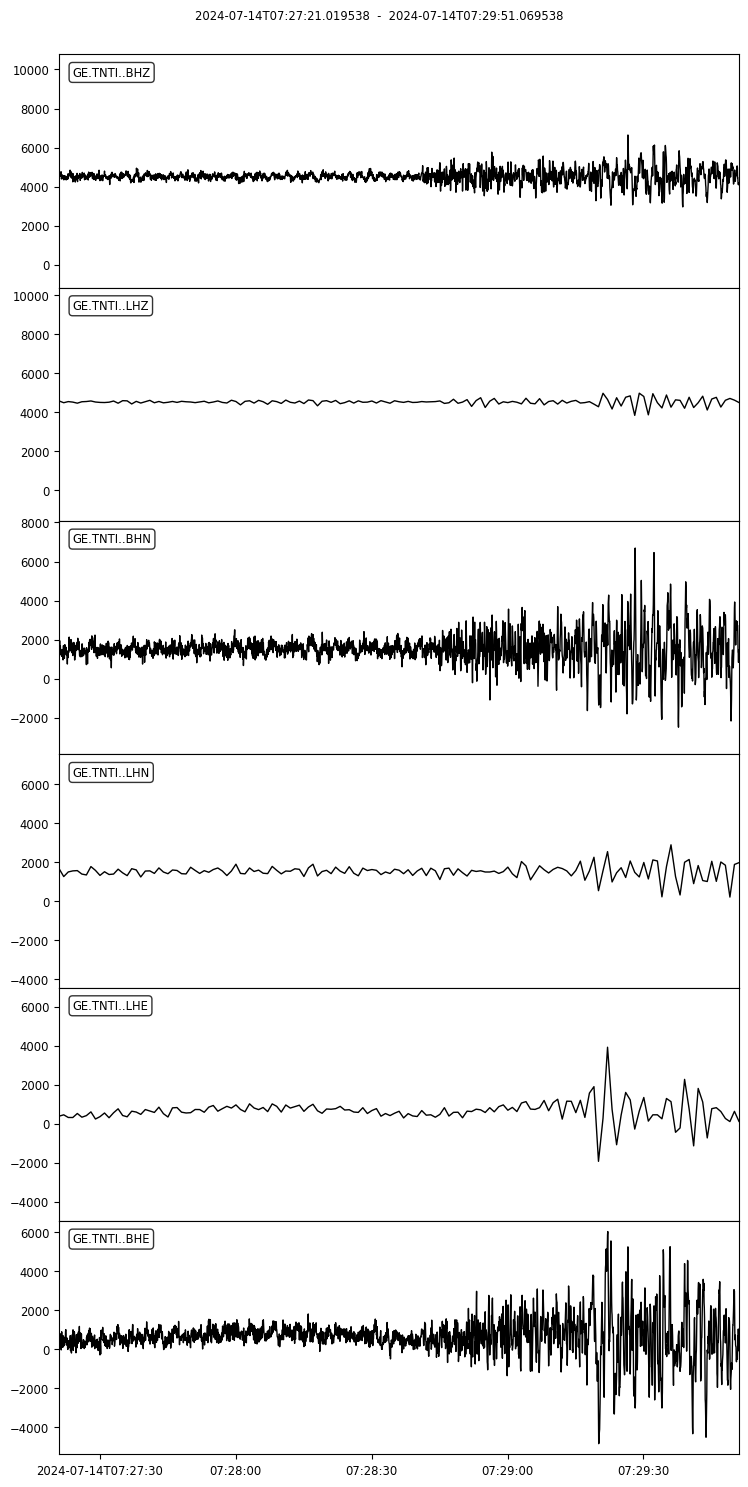

✅ GE_LHMI_20240705_215147.mseed -> 6 trace


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


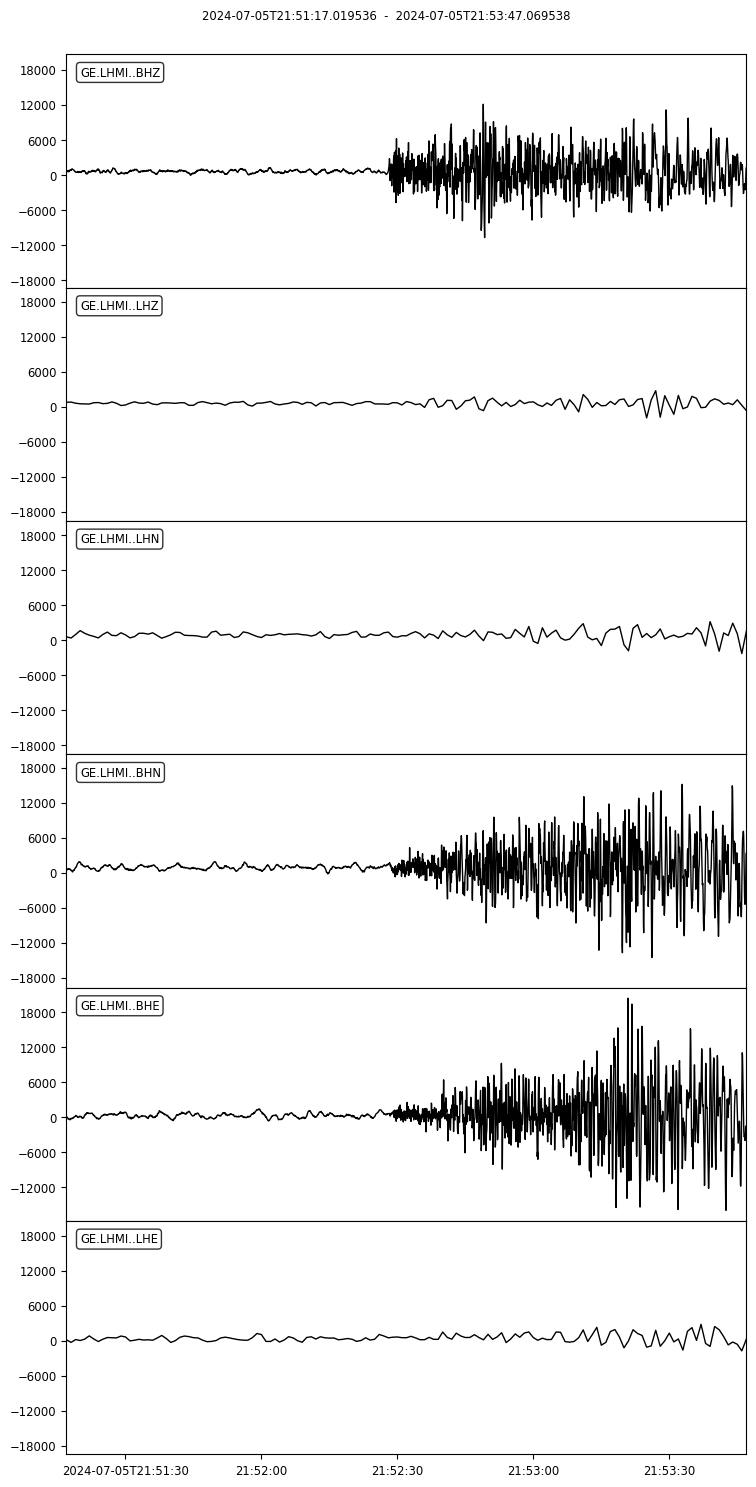

✅ GE_FAKI_20240626_164942.mseed -> 6 trace


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


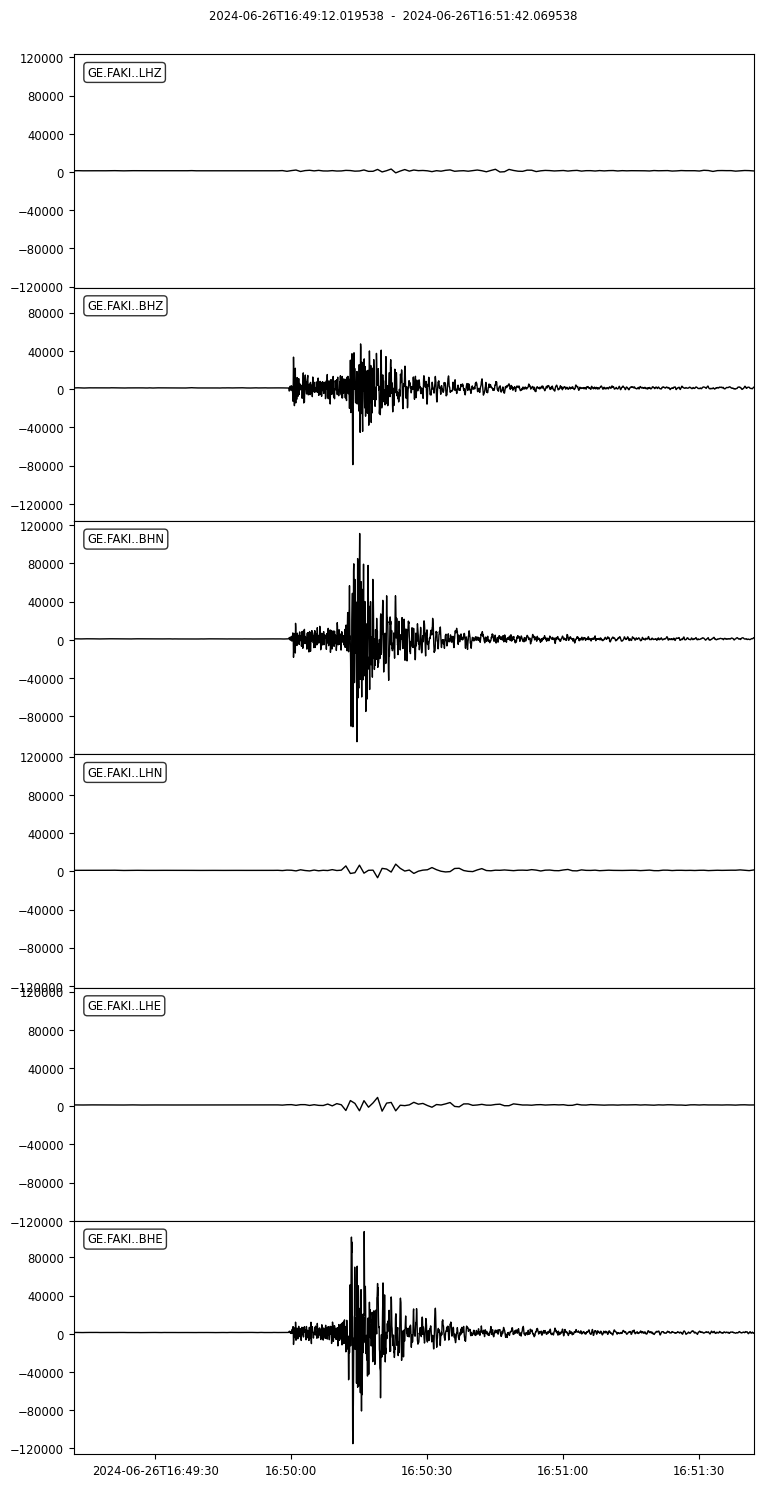

✅ GE_MNAI_20240718_150123.mseed -> 6 trace


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


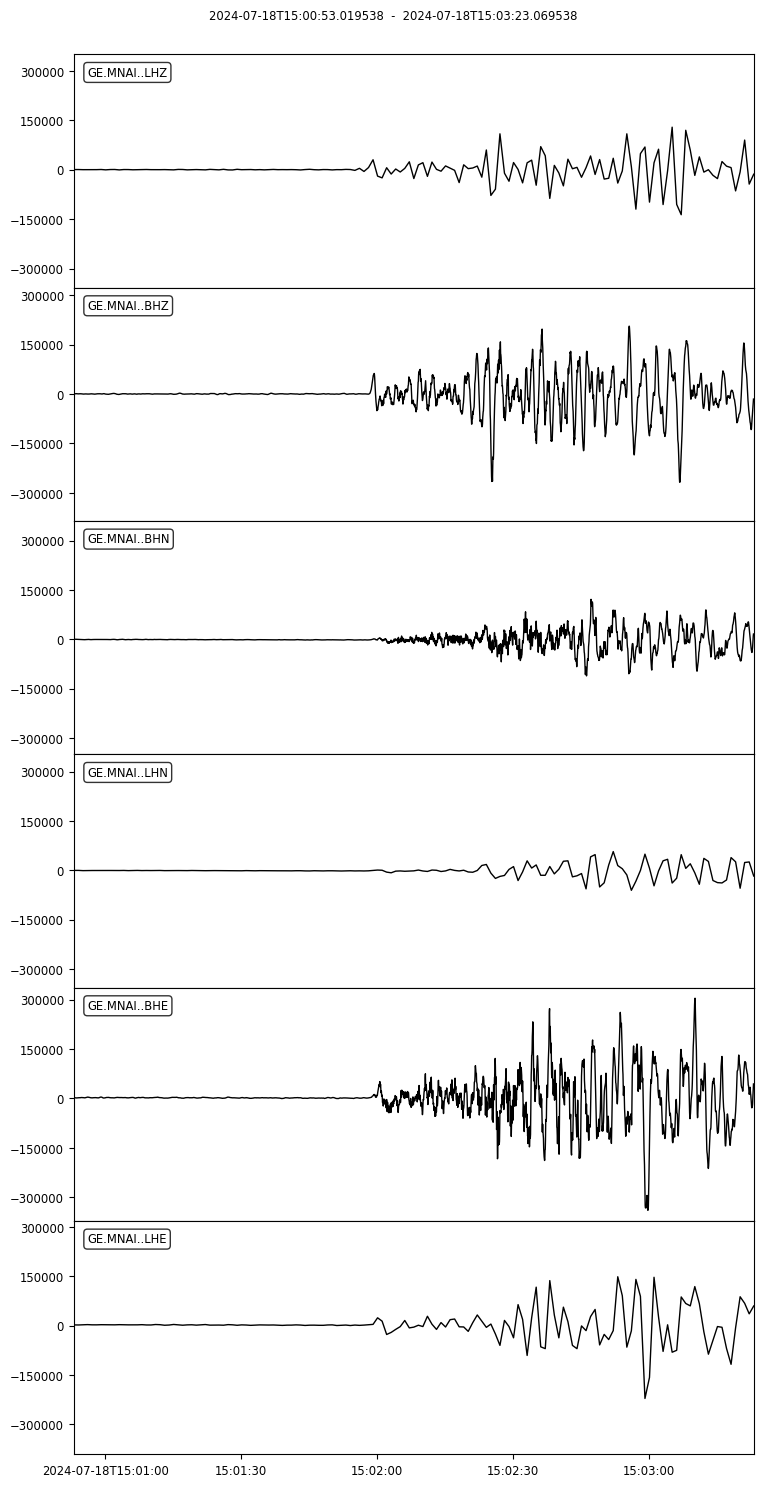

✅ GE_TNTI_20240712_103404.mseed -> 6 trace


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


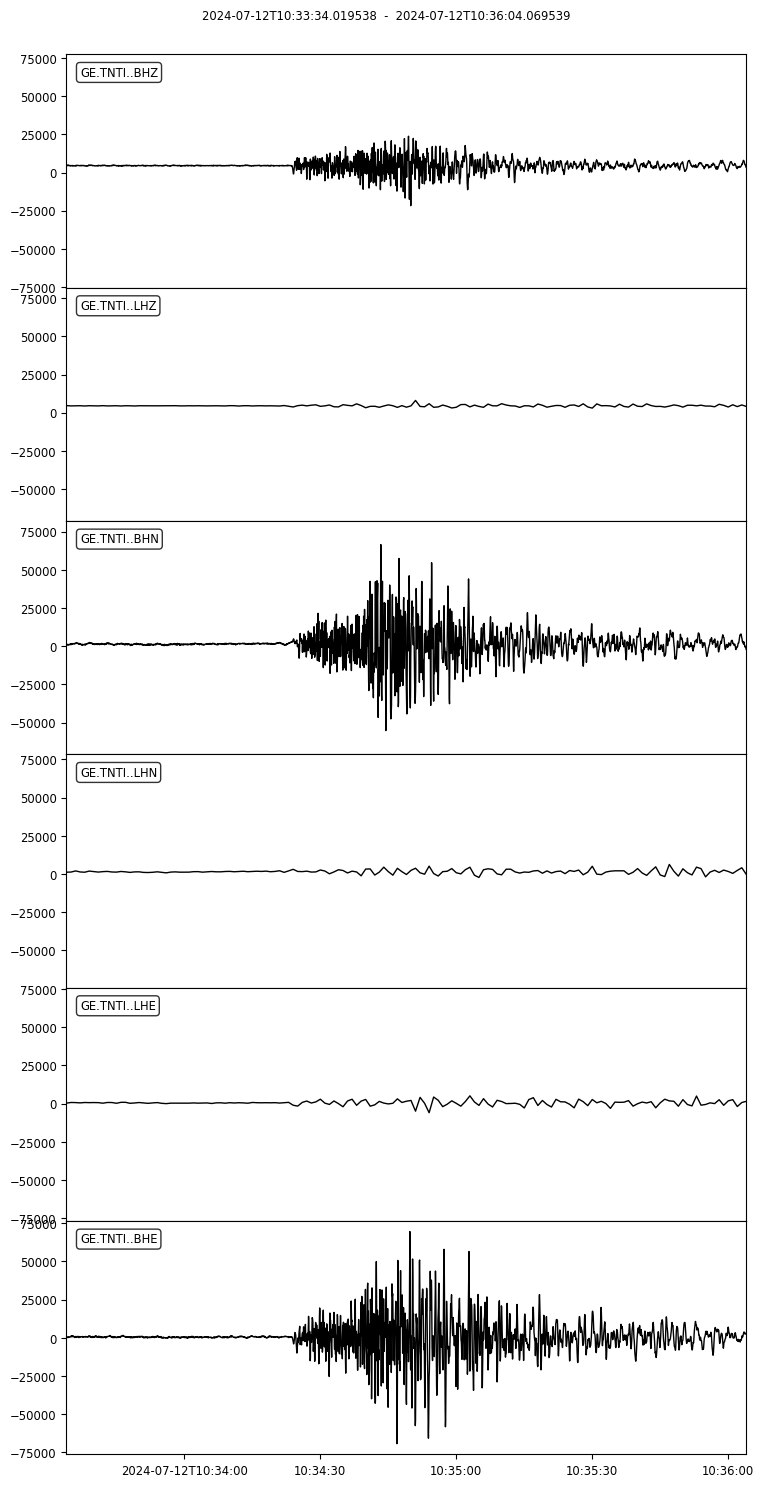

In [31]:
from obspy import read
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Tentukan folder
folder = Path('/Volumes/Extreme SSD/unduhan_juli_indonesia_sesi_4')

# Cari semua file .mseed, kecuali yang diawali ._ (file sistem macOS)
all_files = [
    f for f in folder.glob('*.mseed') 
    if not f.name.startswith('._') and f.stat().st_size > 1024  # minimal 1 KB
]

print(f"Ditemukan {len(all_files)} file .mseed valid (file sistem diabaikan)")

if len(all_files) == 0:
    print("Tidak ada file .mseed valid.")
else:
    # Pilih 5 file acak (jika kurang, ambil semua)
    n_sample = min(5, len(all_files))
    random_files = np.random.choice(all_files, size=n_sample, replace=False)
    
    print(f"\nMengambil {n_sample} file acak:")
    for file_path in random_files:
        try:
            st = read(str(file_path))
            print(f"✅ {file_path.name} -> {len(st)} trace")
            st.plot()  # Plot setiap file
        except Exception as e:
            print(f"❌ Gagal membaca {file_path.name}: {e}")

In [32]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

client = Client("IRIS")

# Contoh: Cari stasiun UGM (Universitas Gadjah Mada) di jaringan GE (GEOFON)
# Jika ingin mencari jaringan IA (BMKG-GEOFON backbone), ganti network="IA"
inventory = client.get_stations(
    network="GE",          # GEOFON (bisa juga "IA" untuk BMKG-GEOFON)
    station="UGM",         # Kode stasiun di Yogyakarta
    starttime=UTCDateTime("2024-01-01T00:00:00"),
    endtime=UTCDateTime("2024-01-02T00:00:00"),
    level="response"       # Dapatkan informasi respons instrumen
)

print(inventory)

/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


Inventory created at 2026-07-16T02:57:10.259300Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.56
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			GE
		Stations (1):
			GE.UGM (GEOFON Station Wanagama, Indonesia)
		Channels (21):
			GE.UGM..BHZ, GE.UGM..BHN, GE.UGM..BHE, GE.UGM..HHZ, GE.UGM..HHN, 
			GE.UGM..HHE, GE.UGM..HNZ, GE.UGM..HNN, GE.UGM..HNE, GE.UGM..LHZ, 
			GE.UGM..LHN, GE.UGM..LHE, GE.UGM..SHZ, GE.UGM..SHN, GE.UGM..SHE, 
			GE.UGM..VHZ, GE.UGM..VHN, GE.UGM..VHE, GE.UGM..WDI, GE.UGM..WII, 
			GE.UGM..WKI


In [33]:
import numpy as np
data = st[0].data
print(f"Mean: {np.mean(data)}")
print(f"Std dev: {np.std(data)}")
print(f"Min-max: {np.min(data)} - {np.max(data)}")

Mean: 4543.485838053982
Std dev: 3552.0838968900857
Min-max: -21675 - 23767


In [34]:
from obspy import read
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ========================================
# 1. Ambil file .mseed valid
# ========================================
folder = Path('/Volumes/Extreme SSD/unduhan_juli_indonesia_sesi_4')
all_files = [
    f for f in folder.glob("*.mseed")
    if not f.name.startswith("._") and f.stat().st_size > 1024
]
print(f"Ditemukan {len(all_files)} file .mseed valid.")

if not all_files:
    print("Tidak ada file untuk diproses.")
    exit()

# ========================================
# 2. Pilih 5 file acak
# ========================================
n_sample = min(5, len(all_files))
random_files = np.random.choice(all_files, size=n_sample, replace=False)

print(f"\nMemproses {n_sample} file acak:\n")

# ========================================
# 3. Proses dengan filter yang aman secara adaptif
# ========================================
for i, file_path in enumerate(random_files):
    print(f"{i+1}. {file_path.name}")

    try:
        st = read(str(file_path))

        # Detrend
        st.detrend(type="demean")

        # Ambil sampling rate (gunakan trace pertama)
        sr = st[0].stats.sampling_rate
        nyquist = sr / 2.0
        safe_max = nyquist * 0.95  # hindari tepi Nyquist

        # Parameter filter yang diinginkan
        desired_fmin = 1.0
        desired_fmax = 5.0

        # Coba band‑pass
        fmin = desired_fmin
        fmax = min(desired_fmax, safe_max)

        if fmin < fmax:
            # Band‑pass valid
            st.filter(type="bandpass", freqmin=fmin, freqmax=fmax)
            title = f"{file_path.name} (BP {fmin:.1f}-{fmax:.1f} Hz, sr={sr:.1f})"
        else:
            # Band‑pass tidak mungkin → coba high‑pass
            hp_freq = min(desired_fmin, safe_max)
            if hp_freq > 0:
                st.filter(type="highpass", freq=hp_freq)
                title = f"{file_path.name} (HP {hp_freq:.1f} Hz, sr={sr:.1f})"
            else:
                # Nyquist terlalu rendah → tidak ada filter
                title = f"{file_path.name} (TANPA FILTER, sr={sr:.1f})"

        # Plot
        st.plot(size=(800, 600), title=title)

    except Exception as e:
        print(f"   ❌ Gagal memproses: {e}")

print("\nSelesai.")

Ditemukan 36 file .mseed valid.

Memproses 5 file acak:

1. GE_SANI_20240625_042758.mseed
   ❌ Gagal memproses: Selected corner frequency is above Nyquist.
2. GE_FAKI_20240625_212516.mseed
   ❌ Gagal memproses: Selected corner frequency is above Nyquist.
3. GE_GSI_20240712_230623.mseed
   ❌ Gagal memproses: Selected corner frequency is above Nyquist.
4. GE_TNTI_20240714_091047.mseed
   ❌ Gagal memproses: Selected corner frequency is above Nyquist.
5. GE_BBJI_20240630_160626.mseed
   ❌ Gagal memproses: Selected corner frequency is above Nyquist.

Selesai.


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/signal/filter.py:87: UserWarning: Selected high corner frequency (5.0) of bandpass is at or above Nyquist (0.5). Applying a high-pass instead.
  warnings.warn(msg)


Ditemukan 36 file .mseed valid.

Memproses 5 file acak:

1. GE_BNDI_20240714_125117.mseed


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


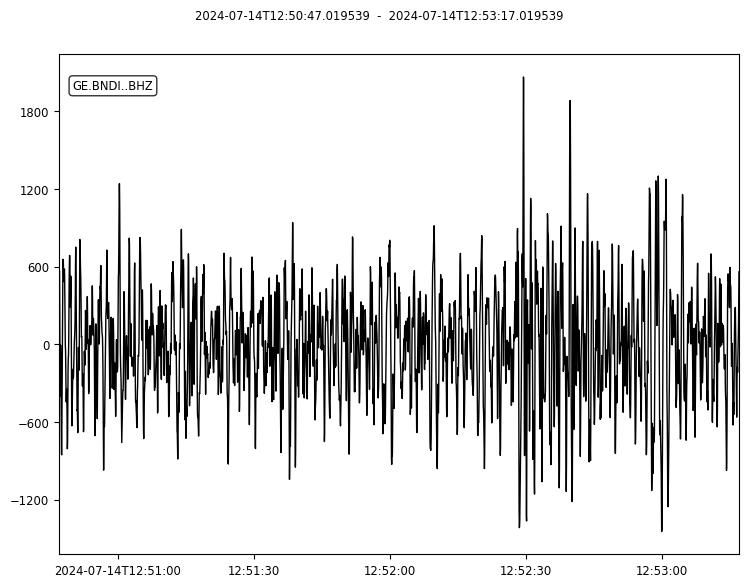

2. GE_TNTI_20240714_072751.mseed


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


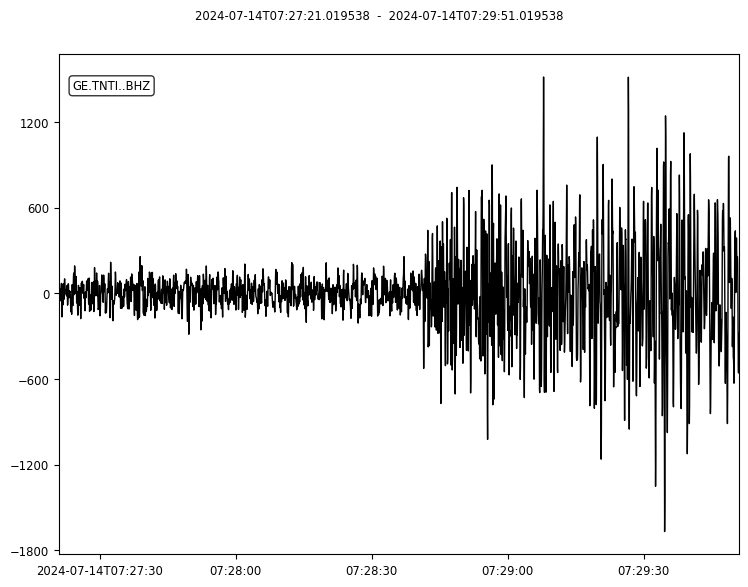

3. GE_FAKI_20240627_104430.mseed


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


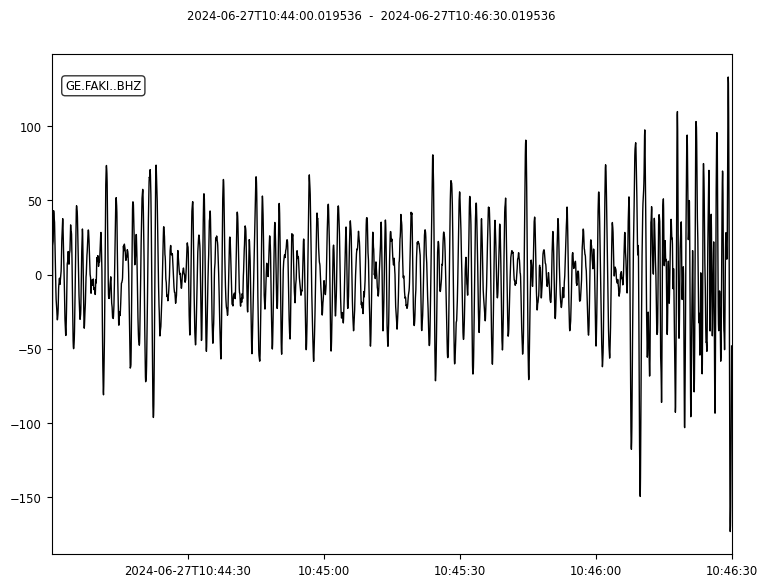

/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


4. GE_SANI_20240625_042758.mseed


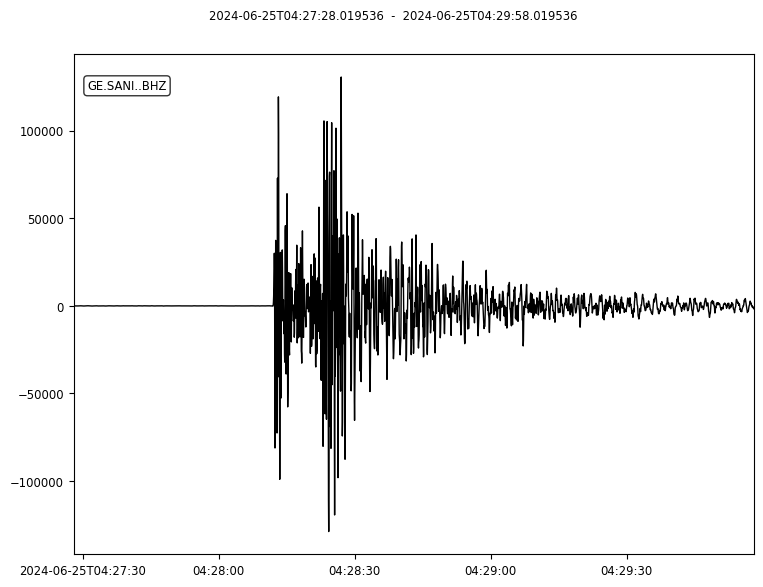

5. GE_SOEI_20240705_072210.mseed


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


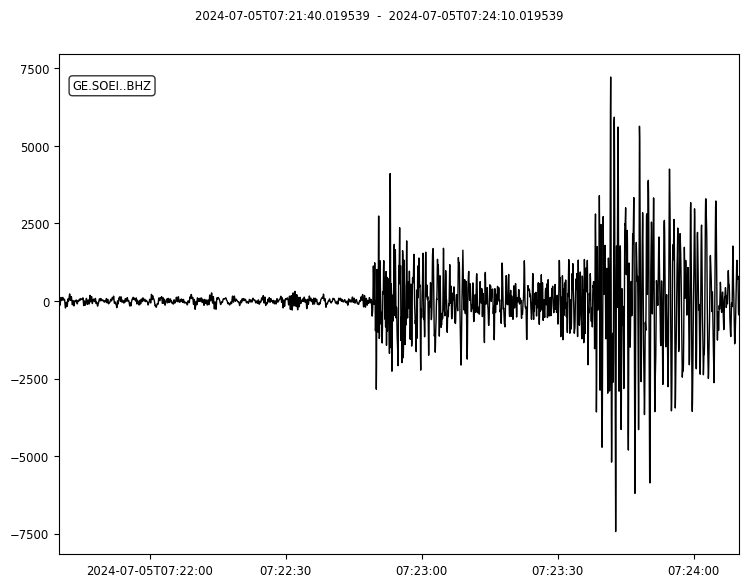


Selesai.


In [35]:
from obspy import read, UTCDateTime
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# =============================================
# 1. Ambil semua file .mseed (skip file sistem)
# =============================================
folder = Path('/Volumes/Extreme SSD/unduhan_juli_indonesia_sesi_4')
all_files = [
    f for f in folder.glob("*.mseed")
    if not f.name.startswith("._") and f.stat().st_size > 1024
]
print(f"Ditemukan {len(all_files)} file .mseed valid.")

if not all_files:
    print("Tidak ada file untuk diproses.")
    exit()

# =============================================
# 2. Pilih 5 file secara acak
# =============================================
n_sample = min(5, len(all_files))
random_files = np.random.choice(all_files, size=n_sample, replace=False)

print(f"\nMemproses {n_sample} file acak:\n")

# =============================================
# 3. Proses setiap file
# =============================================
for i, file_path in enumerate(random_files):
    print(f"{i+1}. {file_path.name}")

    try:
        st = read(str(file_path))

        # ---- Pilih komponen dengan prioritas ----
        # Coba BHZ, lalu HHZ, lalu LHZ, atau ambil trace pertama
        selected = st.select(channel="BHZ")
        if len(selected) == 0:
            selected = st.select(channel="HHZ")
        if len(selected) == 0:
            selected = st.select(channel="LHZ")
        if len(selected) == 0:
            # fallback: ambil trace pertama yang ada
            selected = st[0:1].copy()
            print(f"   ⚠️  Tidak ada channel Z standar, gunakan {selected[0].stats.channel}")

        # ---- Detrend ----
        selected.detrend("demean")

        # ---- Dapatkan sampling rate ----
        sr = selected[0].stats.sampling_rate
        nyquist = sr / 2.0
        safe_max = nyquist * 0.95  # hindari tepi Nyquist

        # ---- Terapkan filter adaptif ----
        if sr >= 10:
            # Bandpass 0.5–5 Hz (atau kurang jika Nyquist rendah)
            fmin = 0.5
            fmax = min(5.0, safe_max)
            if fmin < fmax:
                selected.filter("bandpass", freqmin=fmin, freqmax=fmax)
                filter_label = f"BP {fmin:.1f}-{fmax:.1f} Hz"
            else:
                # Nyquist terlalu rendah, high‑pass
                hp = min(1.0, safe_max)
                if hp > 0.01:
                    selected.filter("highpass", freq=hp)
                    filter_label = f"HP {hp:.1f} Hz"
                else:
                    filter_label = "Tanpa filter (Nyquist ~0)"
        else:
            # Sampling rate rendah → lowpass
            low = min(0.4, safe_max)
            if low > 0.01:
                selected.filter("lowpass", freq=low)
                filter_label = f"LP {low:.1f} Hz"
            else:
                filter_label = "Tanpa filter (Nyquist ~0)"

        # ---- Plot ----
        title = f"{file_path.name}\n{sr:.1f} Hz, {filter_label}"
        selected.plot(size=(800, 600), title=title)

    except Exception as e:
        print(f"   ❌ Gagal memproses: {e}")

print("\nSelesai.")

Sampling rate: 20.0 Hz


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


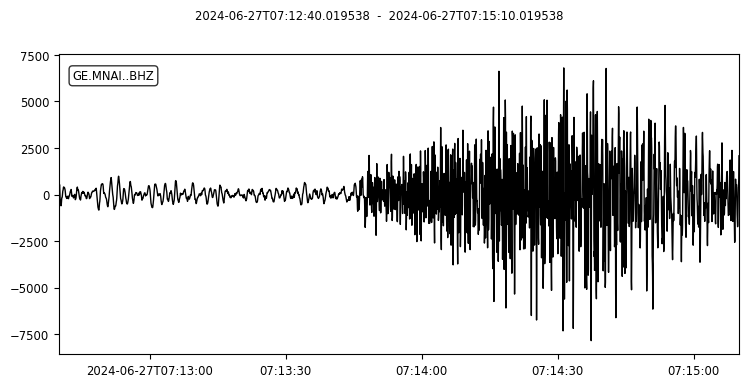

Mean: -1.7466071305193653
Std dev: 1438.2308070332672


In [36]:
from obspy import read, UTCDateTime
import matplotlib.pyplot as plt

# Baca file
st = read('/Volumes/Extreme SSD/unduhan_juli_indonesia_sesi_4/GE_MNAI_20240627_071310.mseed')

# Ambil hanya BHZ
st_bhz = st.select(channel="BHZ")

# Periksa apakah BHZ ada
if len(st_bhz) == 0:
    print("BHZ tidak ditemukan, coba channel lain")
    st_bhz = st.select(channel="HHZ")
    if len(st_bhz) == 0:
        st_bhz = st.select(channel="LHZ")

# 1. Hilangkan offset DC
st_bhz.detrend("demean")

# 2. Periksa sampling rate
sr = st_bhz[0].stats.sampling_rate
print(f"Sampling rate: {sr} Hz")

# 3. Filter sesuai sampling rate
if sr >= 10:
    st_bhz.filter("bandpass", freqmin=0.5, freqmax=min(5.0, sr/2 - 0.1))
else:
    # Untuk LHZ (low sampling rate)
    st_bhz.filter("lowpass", freq=min(0.4, sr/2 - 0.1))

# 4. Plot
st_bhz.plot(size=(800, 400))

# 5. Tampilkan statistik setelah preprocessing
print(f"Mean: {st_bhz[0].data.mean()}")
print(f"Std dev: {st_bhz[0].data.std()}")

Ditemukan 36 file .mseed valid.

Memproses 5 file acak:


1. GE_JAGI_20240704_113733.mseed
   Jumlah trace dalam stream: 6
   Channel yang tersedia:
     - JAGI, BHZ, sampling_rate=20.0 Hz, durasi=150.0 s
     - JAGI, BHN, sampling_rate=20.0 Hz, durasi=150.0 s
     - JAGI, BHE, sampling_rate=20.0 Hz, durasi=150.0 s
     - JAGI, LHZ, sampling_rate=1.0 Hz, durasi=150.0 s
     - JAGI, LHN, sampling_rate=1.0 Hz, durasi=150.0 s
     - JAGI, LHE, sampling_rate=1.0 Hz, durasi=150.0 s


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


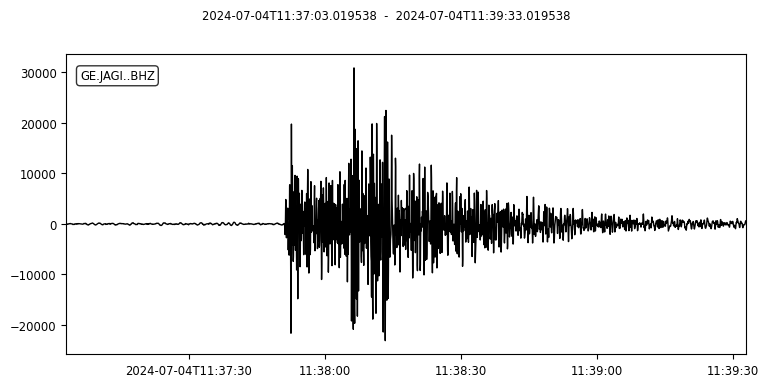


2. GE_TNTI_20240714_072751.mseed
   Jumlah trace dalam stream: 6
   Channel yang tersedia:
     - TNTI, BHZ, sampling_rate=20.0 Hz, durasi=150.0 s
     - TNTI, BHN, sampling_rate=20.0 Hz, durasi=150.0 s
     - TNTI, BHE, sampling_rate=20.0 Hz, durasi=150.0 s
     - TNTI, LHZ, sampling_rate=1.0 Hz, durasi=150.0 s
     - TNTI, LHN, sampling_rate=1.0 Hz, durasi=150.0 s
     - TNTI, LHE, sampling_rate=1.0 Hz, durasi=150.0 s


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


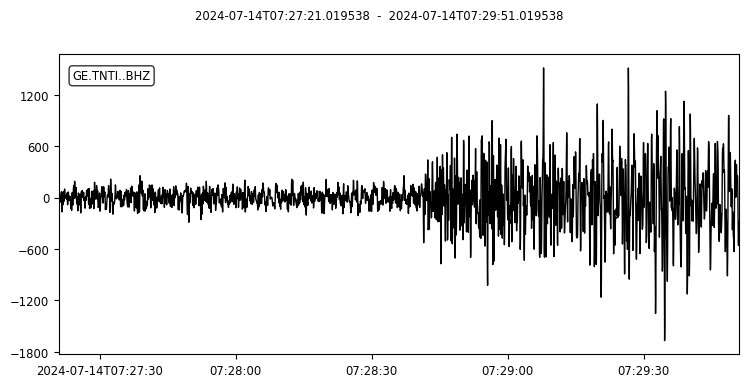


3. GE_SANI_20240712_115010.mseed
   Jumlah trace dalam stream: 6
   Channel yang tersedia:
     - SANI, BHZ, sampling_rate=20.0 Hz, durasi=150.0 s
     - SANI, BHN, sampling_rate=20.0 Hz, durasi=150.0 s
     - SANI, BHE, sampling_rate=20.0 Hz, durasi=150.0 s
     - SANI, LHZ, sampling_rate=1.0 Hz, durasi=150.0 s
     - SANI, LHN, sampling_rate=1.0 Hz, durasi=150.0 s
     - SANI, LHE, sampling_rate=1.0 Hz, durasi=150.0 s


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


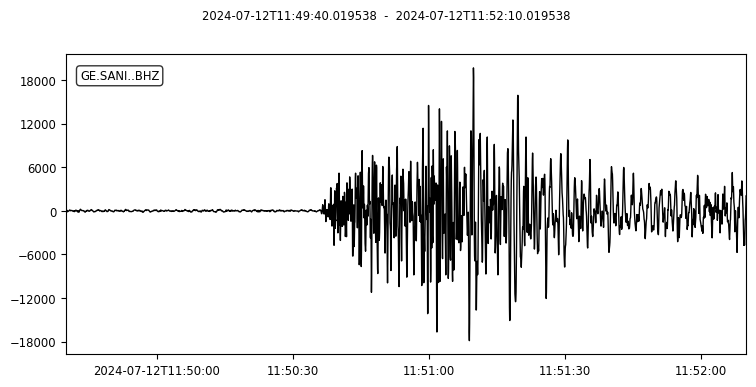


4. GE_BBJI_20240630_160626.mseed


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


   Jumlah trace dalam stream: 6
   Channel yang tersedia:
     - BBJI, BHZ, sampling_rate=20.0 Hz, durasi=150.0 s
     - BBJI, BHN, sampling_rate=20.0 Hz, durasi=150.0 s
     - BBJI, BHE, sampling_rate=20.0 Hz, durasi=150.0 s
     - BBJI, LHZ, sampling_rate=1.0 Hz, durasi=150.0 s
     - BBJI, LHN, sampling_rate=1.0 Hz, durasi=150.0 s
     - BBJI, LHE, sampling_rate=1.0 Hz, durasi=150.0 s


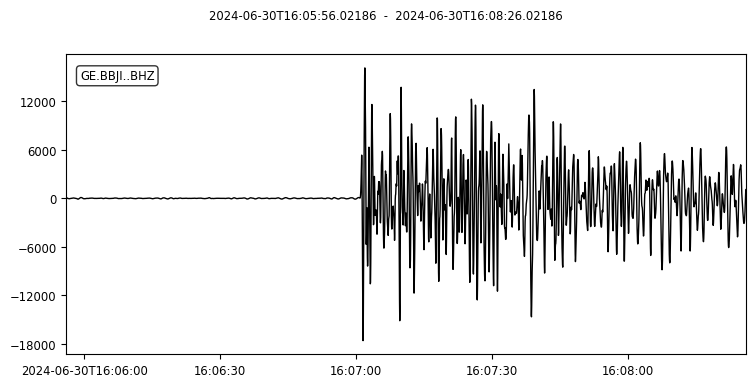


5. GE_LHMI_20240705_215147.mseed
   Jumlah trace dalam stream: 6
   Channel yang tersedia:
     - LHMI, BHZ, sampling_rate=20.0 Hz, durasi=150.0 s
     - LHMI, BHN, sampling_rate=20.0 Hz, durasi=150.0 s
     - LHMI, BHE, sampling_rate=20.0 Hz, durasi=150.0 s
     - LHMI, LHZ, sampling_rate=1.0 Hz, durasi=150.0 s
     - LHMI, LHN, sampling_rate=1.0 Hz, durasi=150.0 s
     - LHMI, LHE, sampling_rate=1.0 Hz, durasi=150.0 s


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


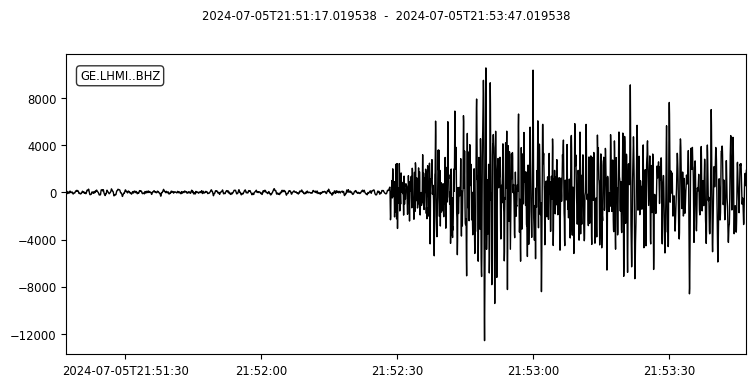


Selesai.


In [37]:
from obspy import read, UTCDateTime
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================
# 1. Ambil semua file .mseed (skip file sistem)
# ============================================
folder = Path('/Volumes/Extreme SSD/unduhan_juli_indonesia_sesi_4')
all_files = [
    f for f in folder.glob("*.mseed")
    if not f.name.startswith("._") and f.stat().st_size > 1024
]
print(f"Ditemukan {len(all_files)} file .mseed valid.")

if not all_files:
    print("Tidak ada file untuk diproses.")
    exit()

# ============================================
# 2. Pilih 5 file secara acak
# ============================================
n_sample = min(5, len(all_files))
random_files = np.random.choice(all_files, size=n_sample, replace=False)

print(f"\nMemproses {n_sample} file acak:\n")

# ============================================
# 3. Proses setiap file
# ============================================
for i, file_path in enumerate(random_files):
    print(f"\n{i+1}. {file_path.name}")

    try:
        # ---- Baca file ----
        st = read(str(file_path))
        print(f"   Jumlah trace dalam stream: {len(st)}")

        # ---- Tampilkan channel yang tersedia (debug) ----
        print("   Channel yang tersedia:")
        for tr in st:
            print(f"     - {tr.stats.station}, {tr.stats.channel}, "
                  f"sampling_rate={tr.stats.sampling_rate:.1f} Hz, "
                  f"durasi={tr.stats.endtime - tr.stats.starttime:.1f} s")

        # ---- Pilih channel Z dengan prioritas ----
        selected = st.select(channel="BHZ")
        if len(selected) == 0:
            selected = st.select(channel="HHZ")
        if len(selected) == 0:
            selected = st.select(channel="LHZ")
        if len(selected) == 0:
            # Fallback: ambil trace pertama (apapun channelnya)
            selected = st[0:1].copy()
            print(f"   ⚠️  Tidak ada channel Z standar, gunakan {selected[0].stats.channel}")

        # ---- Detrend ----
        selected.detrend("demean")

        # ---- Ambil sampling rate ----
        sr = selected[0].stats.sampling_rate
        nyquist = sr / 2.0
        safe_max = nyquist * 0.95  # batas aman untuk filter

        # ---- Filter adaptif (tanpa slicing) ----
        if sr >= 10:
            fmin = 0.5
            fmax = min(5.0, safe_max)
            if fmin < fmax:
                selected.filter("bandpass", freqmin=fmin, freqmax=fmax)
                filter_label = f"BP {fmin:.1f}-{fmax:.1f} Hz"
            else:
                hp = min(1.0, safe_max)
                if hp > 0.01:
                    selected.filter("highpass", freq=hp)
                    filter_label = f"HP {hp:.1f} Hz"
                else:
                    filter_label = "Tanpa filter (Nyquist ~0)"
        else:
            low = min(0.4, safe_max)
            if low > 0.01:
                selected.filter("lowpass", freq=low)
                filter_label = f"LP {low:.1f} Hz"
            else:
                filter_label = "Tanpa filter (Nyquist ~0)"

        # ---- Plot seluruh data (tanpa slice) ----
        title = f"{file_path.name}\n{sr:.1f} Hz, {filter_label}"
        selected.plot(size=(800, 400), title=title)

    except Exception as e:
        print(f"   ❌ Gagal memproses: {e}")

print("\nSelesai.")

Ditemukan 36 file .mseed valid.

Memproses 5 file acak:


1. GE_TNTI_20240705_182057.mseed
   Sampling rate: 20.0 Hz


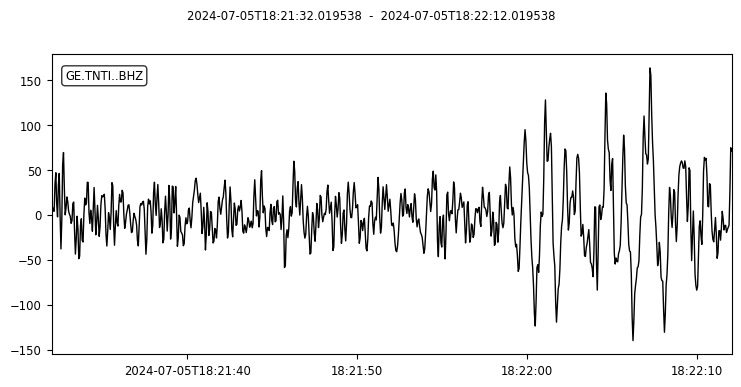


2. GE_TNTI_20240717_191743.mseed
   Sampling rate: 20.0 Hz


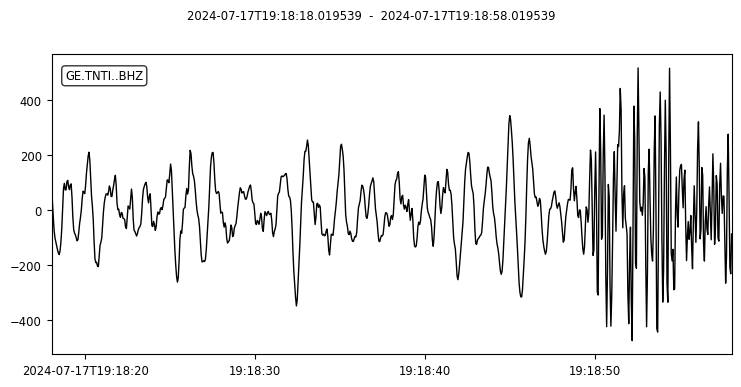


3. GE_TNTI_20240714_072751.mseed
   Sampling rate: 20.0 Hz


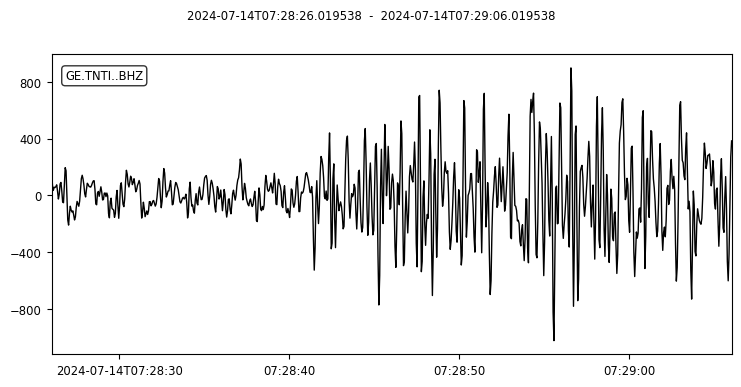


4. GE_TNTI_20240714_120334.mseed
   Sampling rate: 20.0 Hz


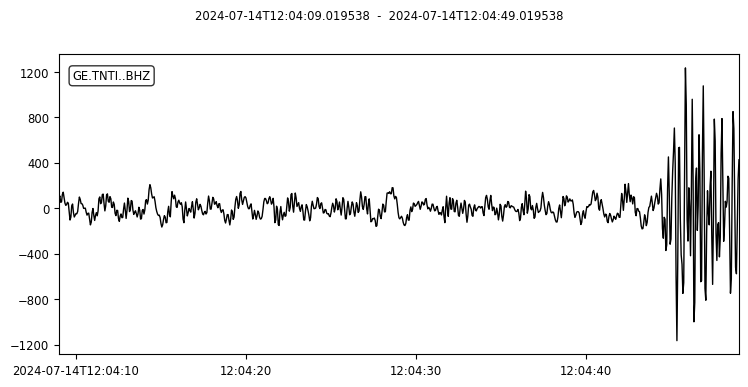


5. GE_TNTI_20240719_143133.mseed
   Sampling rate: 20.0 Hz


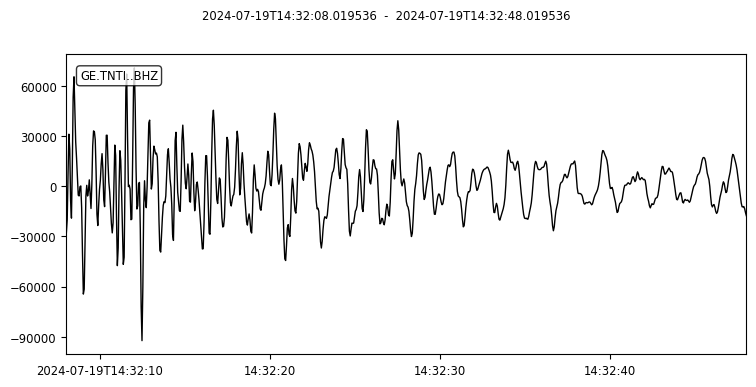


Selesai.


In [38]:
from obspy import read, UTCDateTime
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================
# 1. Ambil semua file .mseed (skip file sistem)
# ============================================
folder = Path('/Volumes/Extreme SSD/unduhan_juli_indonesia_sesi_4')
all_files = [
    f for f in folder.glob("*.mseed")
    if not f.name.startswith("._") and f.stat().st_size > 1024
]
print(f"Ditemukan {len(all_files)} file .mseed valid.")

if not all_files:
    print("Tidak ada file untuk diproses.")
    exit()

# ============================================
# 2. Pilih 5 file secara acak
# ============================================
n_sample = min(5, len(all_files))
random_files = np.random.choice(all_files, size=n_sample, replace=False)

print(f"\nMemproses {n_sample} file acak:\n")

# ============================================
# 3. Proses setiap file
# ============================================
for i, file_path in enumerate(random_files):
    print(f"\n{i+1}. {file_path.name}")

    try:
        st = read(str(file_path))

        # ---- Pilih channel Z dengan prioritas ----
        st_bhz = st.select(channel="BHZ")
        if len(st_bhz) == 0:
            st_bhz = st.select(channel="HHZ")
        if len(st_bhz) == 0:
            st_bhz = st.select(channel="LHZ")
        if len(st_bhz) == 0:
            # fallback: ambil trace pertama
            st_bhz = st[0:1].copy()
            print(f"   ⚠️  Tidak ada channel Z standar, gunakan {st_bhz[0].stats.channel}")

        # ---- Detrend ----
        st_bhz.detrend("demean")

        # ---- Dapatkan sampling rate ----
        sr = st_bhz[0].stats.sampling_rate
        nyquist = sr / 2.0
        safe_max = nyquist * 0.95
        print(f"   Sampling rate: {sr:.1f} Hz")

        # ---- Filter adaptif ----
        if sr >= 10:
            fmin = 0.5
            fmax = min(5.0, safe_max)
            if fmin < fmax:
                st_bhz.filter("bandpass", freqmin=fmin, freqmax=fmax)
                filter_label = f"BP {fmin:.1f}-{fmax:.1f} Hz"
            else:
                hp = min(1.0, safe_max)
                if hp > 0.01:
                    st_bhz.filter("highpass", freq=hp)
                    filter_label = f"HP {hp:.1f} Hz"
                else:
                    filter_label = "Tanpa filter"
        else:
            low = min(0.4, safe_max)
            if low > 0.01:
                st_bhz.filter("lowpass", freq=low)
                filter_label = f"LP {low:.1f} Hz"
            else:
                filter_label = "Tanpa filter"

        # ---- Slicing di sekitar tengah data ----
        ref = st_bhz[0]
        durasi = ref.stats.endtime - ref.stats.starttime
        if durasi > 40:  # jika cukup panjang, ambil 40 detik di tengah
            mid = ref.stats.starttime + durasi / 2
            start_slice = mid - 10
            end_slice = mid + 30
            # batasi agar tidak keluar jangkauan data
            if start_slice < ref.stats.starttime:
                start_slice = ref.stats.starttime
            if end_slice > ref.stats.endtime:
                end_slice = ref.stats.endtime
            st_slice = st_bhz.slice(starttime=start_slice, endtime=end_slice)
        else:
            st_slice = st_bhz.copy()
            print(f"   Durasi pendek ({durasi:.1f} s), plot seluruh data.")

        # ---- Cek apakah slice kosong ----
        if len(st_slice) == 0:
            print("   ❌ Slice kosong, lewati plot.")
        else:
            title = f"{file_path.name}\n{sr:.1f} Hz, {filter_label}"
            st_slice.plot(size=(800, 400), title=title)

    except Exception as e:
        print(f"   ❌ Gagal memproses: {e}")

print("\nSelesai.")

Jumlah event dalam JSON: 36
Contoh event_id: ['GE_PMBI_20240705_163113', 'GE_JAGI_20240704_113733', 'GE_MNAI_20240705_185154', 'GE_LHMI_20240705_215147', 'GE_BBJI_20240630_205201']

Memvisualisasikan 5 event acak:


Event: GE_TNTI_20240712_103404
  Station: GE.TNTI
  P arrival: 2024-07-12T10:34:10.069538Z


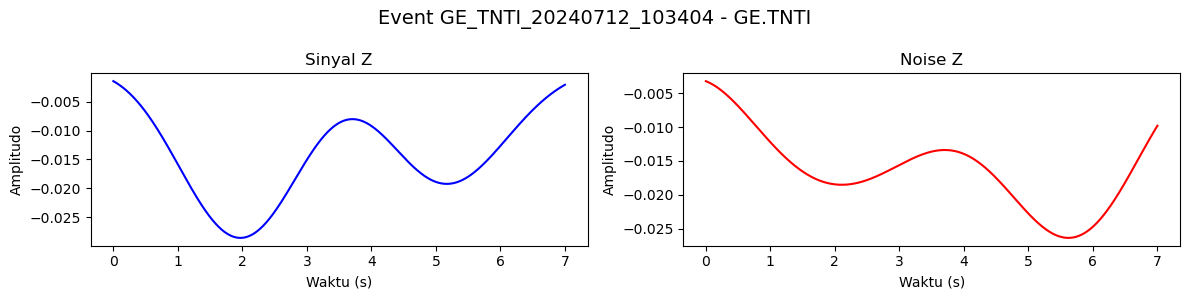


Event: GE_TNTI_20240714_091047
  Station: GE.TNTI
  P arrival: 2024-07-14T09:10:57.069538Z


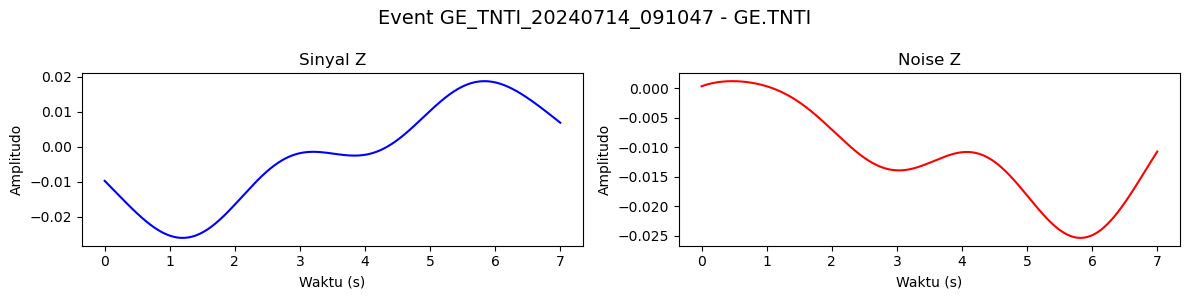


Event: GE_TNTI_20240714_072751
  Station: GE.TNTI
  P arrival: 2024-07-14T07:27:59.069538Z


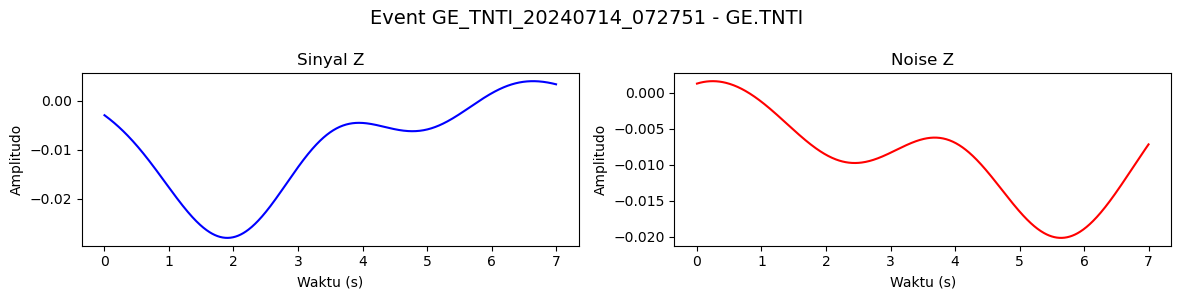


Event: GE_MNAI_20240713_184925
  Station: GE.MNAI
  P arrival: 2024-07-13T18:49:31.069538Z


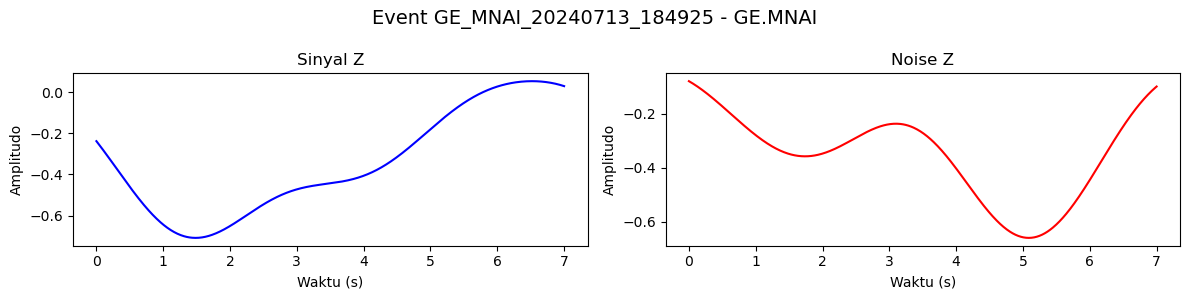


Event: GE_MNAI_20240630_041331
  Station: GE.MNAI
  P arrival: 2024-06-30T04:13:25.069538Z


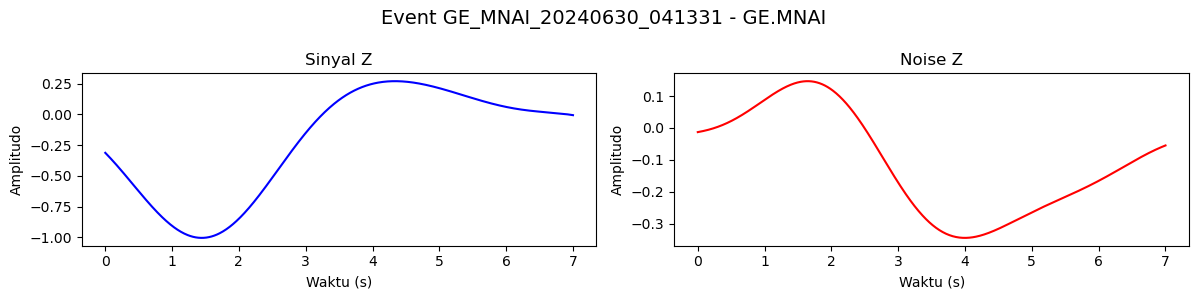

In [39]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================
# 1. Tentukan path file JSON (1C atau 3C)
# ============================================
JSON_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4.json'  # Ganti sesuai kebutuhan

# ============================================
# 2. Load data
# ============================================
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"Jumlah event dalam JSON: {len(data)}")

# Ambil daftar event_id
event_ids = list(data.keys())
print(f"Contoh event_id: {event_ids[:5]}")

# ============================================
# 3. Pilih 5 event secara acak
# ============================================
n_sample = min(5, len(data))
random_ids = np.random.choice(event_ids, size=n_sample, replace=False)

print(f"\nMemvisualisasikan {n_sample} event acak:\n")

# ============================================
# 4. Plot sinyal dan noise untuk setiap event
# ============================================
for event_id in random_ids:
    event = data[event_id]
    
    # Ambil metadata
    meta = event.get('metadata', {})
    station = meta.get('station', 'unknown')
    network = meta.get('network', 'unknown')
    p_arrival = meta.get('p_arrival', 'unknown')
    
    print(f"\nEvent: {event_id}")
    print(f"  Station: {network}.{station}")
    print(f"  P arrival: {p_arrival}")
    
    # Sinyal dan noise
    signal_z = np.array(event.get('Z', []))
    noise_z = np.array(event.get('Z_noise', []))
    has_n = 'N' in event
    has_e = 'E' in event
    
    # Tentukan jumlah subplot
    n_plots = 1  # minimal Z
    if has_n:
        n_plots += 1
    if has_e:
        n_plots += 1
    
    # Buat figure
    fig, axes = plt.subplots(n_plots, 2, figsize=(12, 3*n_plots))
    if n_plots == 1:
        axes = axes.reshape(1, -1)  # agar indexing 2D tetap
    
    # Fungsi untuk plot
    def plot_trace(ax_signal, ax_noise, signal, noise, title):
        time_signal = np.linspace(0, len(signal)/100, len(signal))
        time_noise = np.linspace(0, len(noise)/100, len(noise))
        ax_signal.plot(time_signal, signal, 'b')
        ax_signal.set_title(f'Sinyal {title}')
        ax_signal.set_xlabel('Waktu (s)')
        ax_signal.set_ylabel('Amplitudo')
        ax_noise.plot(time_noise, noise, 'r')
        ax_noise.set_title(f'Noise {title}')
        ax_noise.set_xlabel('Waktu (s)')
        ax_noise.set_ylabel('Amplitudo')
    
    # Plot Z
    row = 0
    plot_trace(axes[row, 0], axes[row, 1], signal_z, noise_z, 'Z')
    
    # Plot N jika ada
    if has_n:
        row += 1
        signal_n = np.array(event['N'])
        noise_n = np.array(event['N_noise'])
        plot_trace(axes[row, 0], axes[row, 1], signal_n, noise_n, 'N')
    
    # Plot E jika ada
    if has_e:
        row += 1
        signal_e = np.array(event['E'])
        noise_e = np.array(event['E_noise'])
        plot_trace(axes[row, 0], axes[row, 1], signal_e, noise_e, 'E')
    
    # Atur layout dan judul utama
    plt.suptitle(f"Event {event_id} - {network}.{station}", fontsize=14)
    plt.tight_layout()
    plt.show()

Total events dalam JSON: 36

Memvisualisasikan 5 event acak:



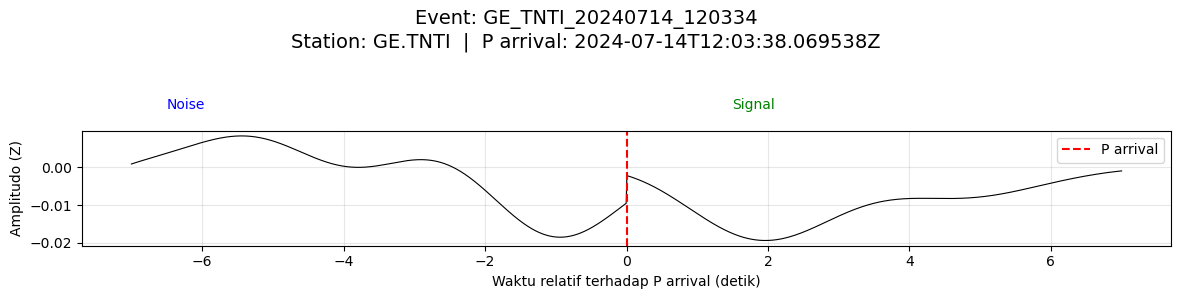

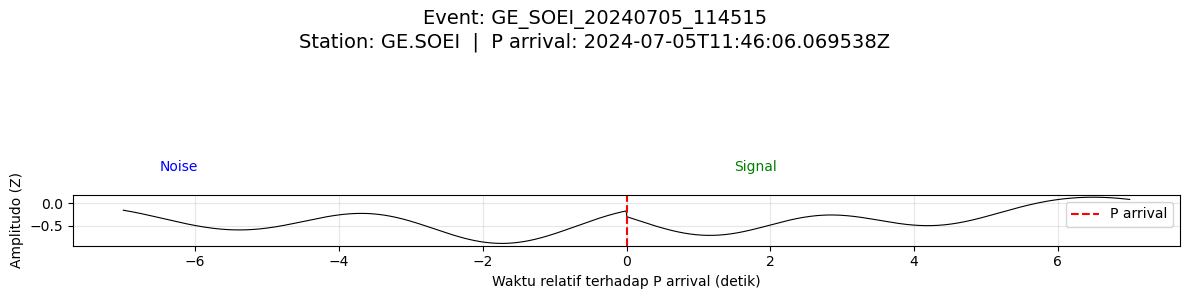

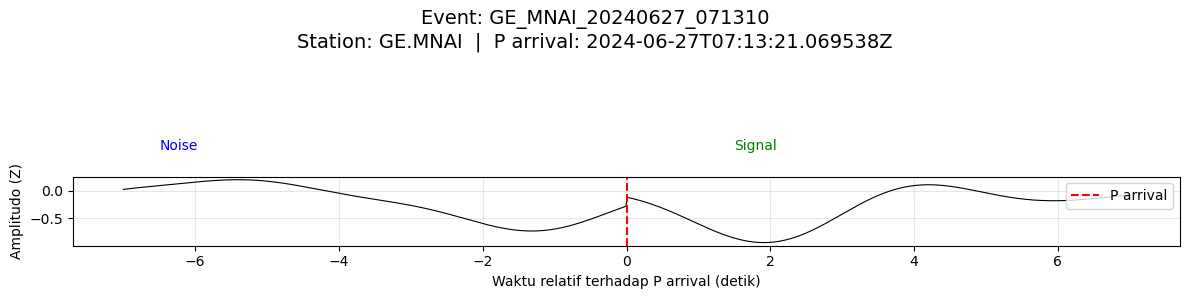

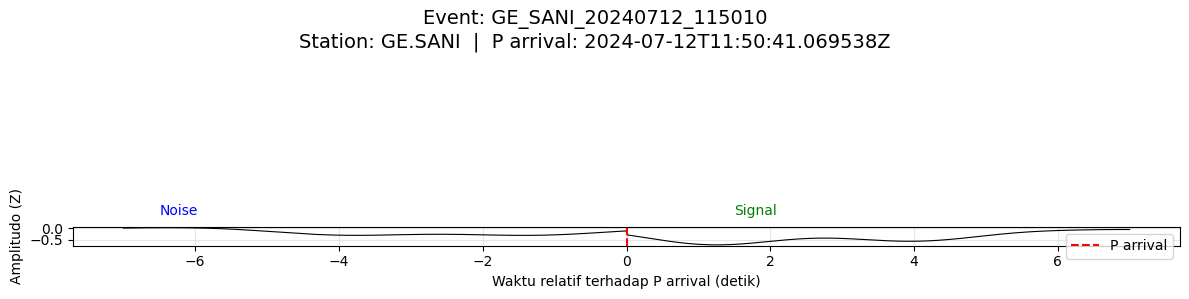

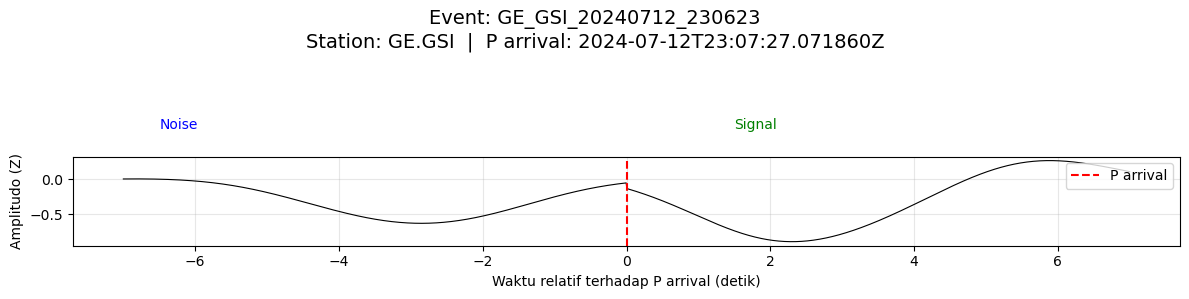

In [40]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =============================================
# 1. Konfigurasi path
# =============================================
JSON_PATH = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_4/extracted_data_1c_4.json'
# Ganti ke file 3C jika perlu: extracted_data_3c.json

# =============================================
# 2. Load data
# =============================================
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"Total events dalam JSON: {len(data)}")

# Ambil daftar event_id
event_ids = list(data.keys())

# =============================================
# 3. Pilih 5 event secara acak
# =============================================
n_sample = min(5, len(data))
selected_ids = np.random.choice(event_ids, size=n_sample, replace=False)

print(f"\nMemvisualisasikan {n_sample} event acak:\n")

# =============================================
# 4. Fungsi plot untuk satu event
# =============================================
def plot_event(event_id, event):
    """
    Plot noise (7 detik sebelum P) dan sinyal (7 detik setelah P)
    dalam satu sumbu waktu kontinu, dengan garis vertikal di P arrival.
    """
    metadata = event.get('metadata', {})
    station = metadata.get('station', 'unknown')
    network = metadata.get('network', 'unknown')
    p_arrival = metadata.get('p_arrival', 'unknown')

    # Tentukan komponen yang tersedia (minimal Z, bisa N dan E)
    components = ['Z']
    if 'N' in event:
        components.append('N')
    if 'E' in event:
        components.append('E')

    # Buat figure dengan subplot per komponen
    fig, axes = plt.subplots(len(components), 1, figsize=(12, 3 * len(components)), sharex=True)
    if len(components) == 1:
        axes = [axes]

    # Waktu relatif terhadap P arrival (dari -7 detik hingga +7 detik)
    time = np.linspace(-7, 7, 1400)  # 700 sampel noise + 700 sampel sinyal

    for idx, comp in enumerate(components):
        signal = np.array(event.get(comp, []))
        noise = np.array(event.get(f'{comp}_noise', []))

        # Jika data tidak lengkap, lewati
        if len(signal) == 0 or len(noise) == 0:
            axes[idx].text(0.5, 0.5, f'Data {comp} tidak tersedia', ha='center', va='center')
            continue

        # Gabungkan noise dan sinyal secara berurutan
        trace = np.concatenate([noise, signal])

        # Plot trace
        axes[idx].plot(time, trace, 'k', linewidth=0.8)

        # Garis vertikal merah di P arrival (t=0)
        axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='P arrival')

        # Anotasi noise dan signal
        axes[idx].text(-6.5, 0.8 * np.max(np.abs(trace)), 'Noise', color='blue', fontsize=10, ha='left')
        axes[idx].text(1.5, 0.8 * np.max(np.abs(trace)), 'Signal', color='green', fontsize=10, ha='left')

        axes[idx].set_ylabel(f'Amplitudo ({comp})')
        axes[idx].grid(alpha=0.3)
        axes[idx].legend(loc='upper right')

    axes[-1].set_xlabel('Waktu relatif terhadap P arrival (detik)')
    plt.suptitle(
        f"Event: {event_id}\nStation: {network}.{station}  |  P arrival: {p_arrival}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

# =============================================
# 5. Proses setiap event yang terpilih
# =============================================
for eid in selected_ids:
    plot_event(eid, data[eid])

In [42]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
SINKRONISASI KATALOG INDONESIA DENGAN JSON WAVEFORM
"""
import json
import pandas as pd
import re
import os
from datetime import datetime, timedelta
import numpy as np

# =============================================
# 1. KONFIGURASI PATH
# =============================================

JSON_INDONESIA_PATH = '/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c.json'
CATALOG_INDONESIA_PATH = "/Volumes/Extreme SSD/katalog/hybrid_catalog_filtered.csv"
JSON_OUTPUT_PATH = '/Volumes/Extreme SSD/indonesia_data_earthquake/sync_katalog_json/extracted_data_3c_sync_v3.json'

# =============================================
# FUNGSI EKSTRAKSI TIMESTAMP DAN VALIDASI
# =============================================

def extract_timestamp_from_key(key):
    """
    Ekstrak timestamp dari key JSON.
    Format yang diharapkan: NET_STA_YYYYMMDD_HHMMSS
    """
    match = re.search(r'(\d{8})_(\d{6})', key)
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    match = re.search(r'(\d{14})', key)
    if match:
        ts = match.group(1)
        return f"{ts[:8]}_{ts[8:]}"
    return None

def validate_sync_result(json_path):
    print("\n[INFO] Validasi hasil sinkronisasi...")
    with open(json_path, 'r') as f:
        data = json.load(f)
    le_count = 0
    no_count = 0
    other_count = 0
    for key, record in data.items():
        label = record.get('type', '').lower()
        if label in ['le', 'se', 'eq', 'earthquake']:
            le_count += 1
        elif label in ['no', 'noise']:
            no_count += 1
        else:
            other_count += 1
    print(f"   🟢 LE (Earthquake): {le_count}")
    print(f"   🔴 NO (Noise): {no_count}")
    print(f"   ⚪ Lainnya: {other_count}")
    return le_count, no_count

# =============================================
# FUNGSI BACA KATALOG
# =============================================

def read_catalog(csv_path):
    print(f"[INFO] Membaca katalog: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"   Total baris: {len(df)}")
    print(f"   Kolom: {df.columns.tolist()}")
    
    time_col = None
    for col in df.columns:
        if 'time' in col.lower() or 'datetime' in col.lower() or 'origin' in col.lower():
            time_col = col
            break
    if time_col is None:
        for col in df.columns:
            if df[col].dtype == 'object':
                try:
                    pd.to_datetime(df[col].iloc[0])
                    time_col = col
                    break
                except:
                    continue
    if time_col is None:
        raise ValueError("❌ Tidak dapat menemukan kolom waktu!")
    
    lat_col = next((col for col in df.columns if 'lat' in col.lower()), None)
    lon_col = next((col for col in df.columns if 'lon' in col.lower()), None)
    mag_col = next((col for col in df.columns if 'mag' in col.lower()), None)
    
    label_col = None
    preferred = ['type', 'label', 'class']
    for col in df.columns:
        if col.lower() in preferred:
            label_col = col
            break
    if label_col is None:
        for col in df.columns:
            if 'type' in col.lower() or 'label' in col.lower() or 'class' in col.lower():
                label_col = col
                break
    
    df['datetime'] = pd.to_datetime(df[time_col], utc=True, format='mixed', errors='coerce')
    # Drop baris dengan datetime invalid
    initial_len = len(df)
    df = df.dropna(subset=['datetime'])
    if len(df) < initial_len:
        print(f"   ⚠️ {initial_len - len(df)} baris di-drop karena datetime invalid")
    
    df['timestamp_key'] = df['datetime'].dt.strftime("%Y%m%d_%H%M%S")
    
    metadata = {
        'time_col': time_col,
        'lat_col': lat_col,
        'lon_col': lon_col,
        'mag_col': mag_col,
        'label_col': label_col
    }
    
    print(f"   Kolom waktu: '{time_col}'")
    print(f"   Kolom latitude: '{lat_col}'")
    print(f"   Kolom longitude: '{lon_col}'")
    if mag_col: print(f"   Kolom magnitude: '{mag_col}'")
    if label_col: print(f"   Kolom label: '{label_col}'")
    
    return df, metadata

# =============================================
# FUNGSI SINKRONISASI
# =============================================

def sync_catalog_to_json(json_path, df_catalog, catalog_metadata, output_path):
    print("\n[INFO] Memuat JSON Indonesia...")
    with open(json_path, 'r') as f:
        data = json.load(f)
    print(f"   Total entri di JSON: {len(data)}")
    
    catalog_dict = {}
    for _, row in df_catalog.iterrows():
        key = row['timestamp_key']
        raw_label = row[catalog_metadata['label_col']] if catalog_metadata['label_col'] else 'earthquake'
        # Mapping label
        if isinstance(raw_label, str):
            lbl = raw_label.lower()
            if 'earthquake' in lbl or 'quake' in lbl:
                mapped_label = 'le'
            else:
                mapped_label = 'no'
        else:
            mapped_label = 'le'  # default
        catalog_dict[key] = {
            'origin_time': row['datetime'].isoformat(),
            'latitude': row[catalog_metadata['lat_col']],
            'longitude': row[catalog_metadata['lon_col']],
            'magnitude': row[catalog_metadata['mag_col']] if catalog_metadata['mag_col'] else None,
            'label': mapped_label
        }
    
    print(f"   Total event di katalog: {len(catalog_dict)}")
    
    matched_count = 0
    unmatched_count = 0
    updated_json = {}
    
    for key, record in data.items():
        ts_str = extract_timestamp_from_key(key)
        if ts_str is None:
            unmatched_count += 1
            record['type'] = 'no'
            updated_json[key] = record
            continue
        
        if ts_str in catalog_dict:
            matched_count += 1
            cat_info = catalog_dict[ts_str]
            record['type'] = cat_info['label']
            if 'metadata' not in record:
                record['metadata'] = {}
            record['metadata']['origin_time'] = cat_info['origin_time']
            record['metadata']['latitude'] = cat_info['latitude']
            record['metadata']['longitude'] = cat_info['longitude']
            if cat_info['magnitude'] is not None:
                record['metadata']['magnitude'] = float(cat_info['magnitude'])
            updated_json[key] = record
        else:
            unmatched_count += 1
            # Jika tidak match, set default sebagai 'no' (noise)
            record['type'] = 'no'
            updated_json[key] = record
    
    print(f"\n[INFO] Hasil sinkronisasi:")
    print(f"   ✅ Match: {matched_count}")
    print(f"   ❌ Tidak match: {unmatched_count}")
    
    with open(output_path, 'w') as f:
        json.dump(updated_json, f, indent=2)
    print(f"[SUCCESS] JSON tersimpan di: {output_path}")
    return matched_count, unmatched_count

# =============================================
# MAIN
# =============================================

if __name__ == "__main__":
    print("="*70)
    print("🔗 SINKRONISASI KATALOG INDONESIA DENGAN JSON WAVEFORM")
    print("="*70)
    
    # Validasi path input
    if not os.path.exists(JSON_INDONESIA_PATH):
        print(f"❌ ERROR: File JSON tidak ditemukan di: {JSON_INDONESIA_PATH}")
        exit(1)
    
    if not os.path.exists(CATALOG_INDONESIA_PATH):
        print(f"❌ ERROR: File katalog tidak ditemukan di: {CATALOG_INDONESIA_PATH}")
        exit(1)
    
    # Buat direktori output jika belum ada
    output_dir = os.path.dirname(JSON_OUTPUT_PATH)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
        print(f"[INFO] Direktori output dibuat: {output_dir}")
    
    # Deklarasikan variabel di luar try
    df_catalog = None
    catalog_metadata = None
    
    try:
        df_catalog, catalog_metadata = read_catalog(CATALOG_INDONESIA_PATH)
    except Exception as e:
        print(f"❌ ERROR membaca katalog: {e}")
        exit(1)
    
    # Pastikan df_catalog tidak kosong
    if df_catalog is None or len(df_catalog) == 0:
        print("❌ ERROR: Katalog kosong atau gagal dibaca.")
        exit(1)
    
    matched, unmatched = sync_catalog_to_json(
        JSON_INDONESIA_PATH,
        df_catalog,
        catalog_metadata,
        JSON_OUTPUT_PATH
    )
    
    le_count, no_count = validate_sync_result(JSON_OUTPUT_PATH)
    
    print("\n" + "="*70)
    print("✅ SINKRONISASI SELESAI!")
    print(f"📂 Output: {JSON_OUTPUT_PATH}")
    print(f"📊 Total event: {matched + unmatched}")
    print(f"   - Earthquake (LE): {le_count}")
    print(f"   - Noise (NO): {no_count}")
    print("="*70)

🔗 SINKRONISASI KATALOG INDONESIA DENGAN JSON WAVEFORM
[INFO] Membaca katalog: /Volumes/Extreme SSD/katalog/hybrid_catalog_filtered.csv
   Total baris: 49842
   Kolom: ['datetime', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source', 'event_id', 'year']
   Kolom waktu: 'datetime'
   Kolom latitude: 'latitude'
   Kolom longitude: 'longitude'
   Kolom magnitude: 'magnitude'

[INFO] Memuat JSON Indonesia...
   Total entri di JSON: 20038
   Total event di katalog: 48231

[INFO] Hasil sinkronisasi:
   ✅ Match: 6701
   ❌ Tidak match: 13337
[SUCCESS] JSON tersimpan di: /Volumes/Extreme SSD/indonesia_data_earthquake/sync_katalog_json/extracted_data_3c_sync_v3.json

[INFO] Validasi hasil sinkronisasi...
   🟢 LE (Earthquake): 6701
   🔴 NO (Noise): 13337
   ⚪ Lainnya: 0

✅ SINKRONISASI SELESAI!
📂 Output: /Volumes/Extreme SSD/indonesia_data_earthquake/sync_katalog_json/extracted_data_3c_sync_v3.json
📊 Total event: 20038
   - Earthquake (LE): 6701
   - Noise (NO): 13337
